In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("StudentGradesAnalysis") \
    .getOrCreate()


In [8]:
df = spark.read.csv("/home/jovyan/data/Dataset.csv", sep=",", header=True, inferSchema=True)
df.show()


+-------------------------------------+
|student_id,student_name,subject,marks|
+-------------------------------------+
|                        1,Ali,Math,78|
|                       2,Sara,Math,85|
|                     3,Ali,Science,66|
|                    4,Sara,Science,90|
|                       5,John,Math,55|
|                    6,John,Science,60|
+-------------------------------------+



In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/home/jovyan/data/Taxi-Dataset.csv')


In [5]:
# Display the first few rows
df.head()

# Check data types
df.dtypes

# Basic statistics
df.describe()


,"trip_id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount,payment_type"
count,10
unique,10
top,"1,1,""2023-01-01 00:00:00"",""2023-01-01 00:15:00..."
freq,1


In [6]:
# Check for missing values
df.isnull().sum()

# Handle missing values (e.g., drop or fill)
df = df.dropna()

# Convert data types if necessary
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])


KeyError: 'pickup_datetime'

Index(['trip_id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'fare_amount', 'payment_type'],
      dtype='object')
   trip_id  vendor_id      pickup_datetime     dropoff_datetime  \
0        1          1  2023-01-01 00:00:00  2023-01-01 00:15:00   
1        2          2  2023-01-01 00:10:00  2023-01-01 00:25:00   
2        3          1  2023-01-01 00:20:00  2023-01-01 00:35:00   
3        4          2  2023-01-01 00:30:00  2023-01-01 00:45:00   
4        5          1  2023-01-01 00:40:00  2023-01-01 00:55:00   

   passenger_count  trip_distance  pickup_longitude  pickup_latitude  \
0                1            2.5          -73.9857          40.7484   
1                2            3.0          -73.9712          40.7831   
2                1            1.5          -73.9949          40.7256   
3                3            4.0          -73.9

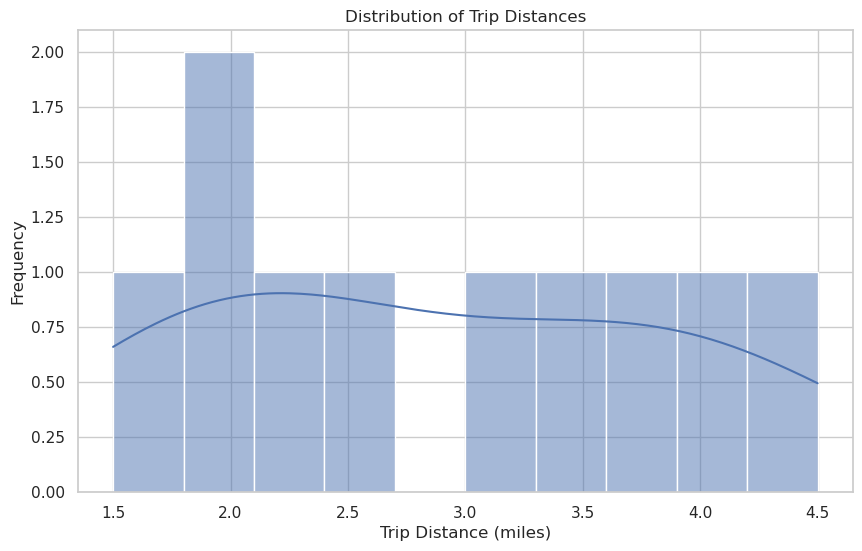

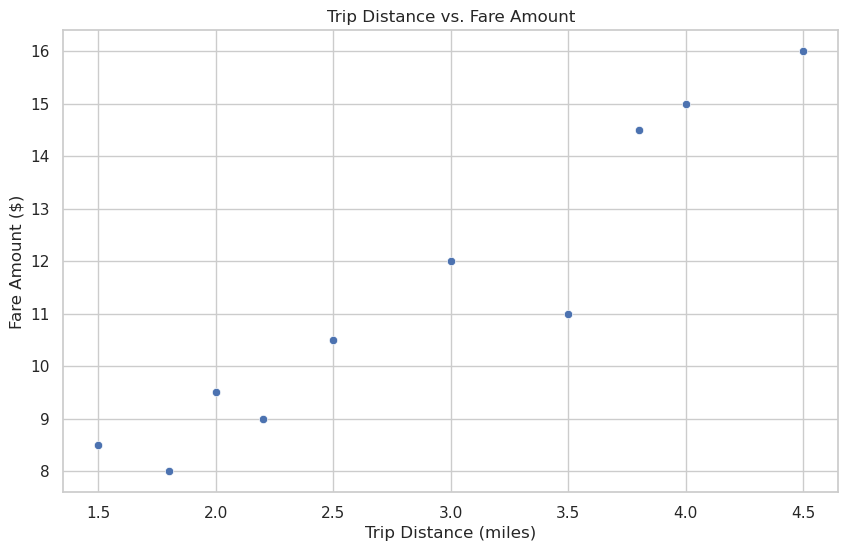

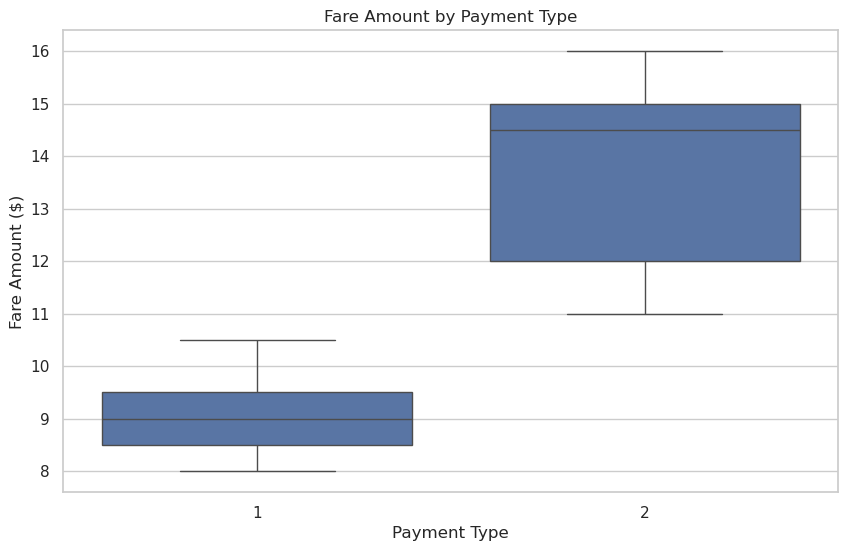

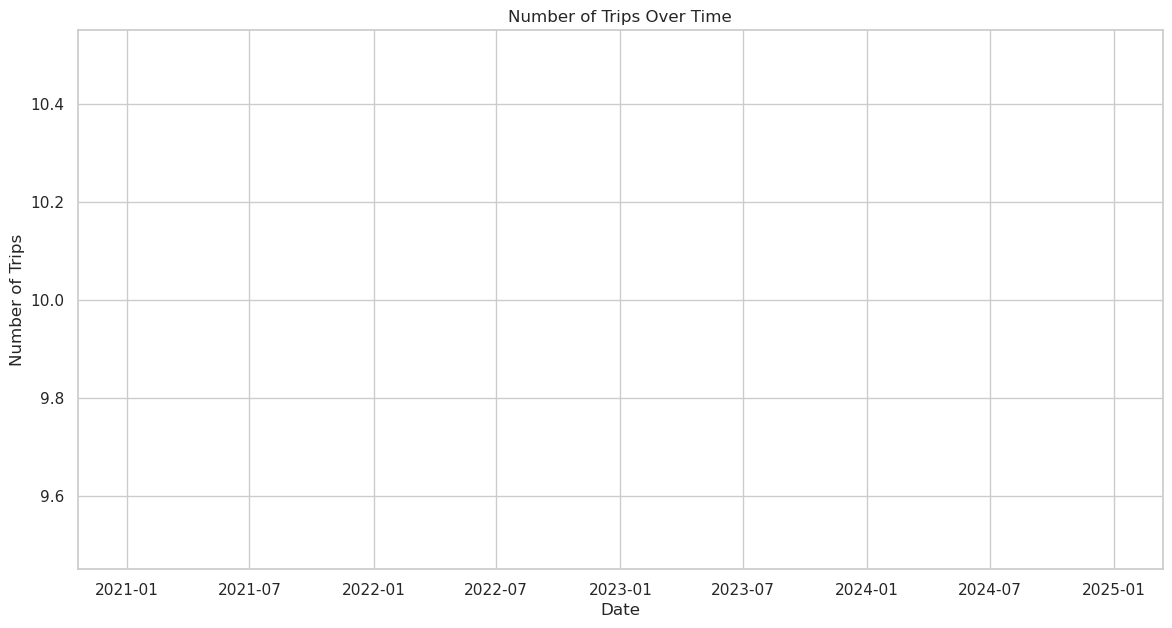

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset with the correct delimiter
df = pd.read_csv('/home/jovyan/data/TripData.csv', sep=',')

# Display the column names to verify
print(df.columns)

# Display the first few rows
print(df.head())

# Check data types
print(df.dtypes)

# Basic statistics
print(df.describe())

# Convert datetime columns if they exist
if 'pickup_datetime' in df.columns and 'dropoff_datetime' in df.columns:
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
    df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])
else:
    print("Column names do not match expected names.")

# Set the style for Seaborn
sns.set(style="whitegrid")

# Histogram of trip distances
plt.figure(figsize=(10, 6))
sns.histplot(df['trip_distance'], bins=10, kde=True)
plt.title('Distribution of Trip Distances')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Frequency')
plt.show()

# Scatter plot of trip distance vs. fare amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='fare_amount', data=df)
plt.title('Trip Distance vs. Fare Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.show()

# Box plot of fare amounts by payment type
plt.figure(figsize=(10, 6))
sns.boxplot(x='payment_type', y='fare_amount', data=df)
plt.title('Fare Amount by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Fare Amount ($)')
plt.show()

# Time series plot of trip counts by pickup datetime
if 'pickup_datetime' in df.columns:
    df['pickup_date'] = df['pickup_datetime'].dt.date
    trip_counts = df.groupby('pickup_date').size()

    plt.figure(figsize=(14, 7))
    trip_counts.plot()
    plt.title('Number of Trips Over Time')
    plt.xlabel('Date')
    plt.ylabel('Number of Trips')
    plt.show()
else:
    print("pickup_datetime column not found.")


In [9]:
df.printSchema()
df.select("student_name", "marks").show()
df.filter(df.marks > 70).show()
df.groupBy("student_name").avg("marks").show()


root
 |-- student_id,student_name,subject,marks: string (nullable = true)



AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `student_name` cannot be resolved. Did you mean one of the following? [`student_id,student_name,subject,marks`].;
'Project ['student_name, 'marks]
+- Relation [student_id,student_name,subject,marks#43] csv
